## **The Algebra of Learning — Part 4: Can It Actually Generalize? (Theory & Diagnosis)**
> **Author:** Isaac Cobena Appiah</br> 
> **Date:** April-2026</br> 
> **Type:** Medium/Substack/Website (talkcodetome.com) Tutorial

*Part 4 comes in two halves. This first half is the theory and the diagnosis: why generalization is hard, what overfitting looks like in maths and in real training curves, and the bias–variance tradeoff that explains all of it. Part 4B will cover the treatments — regularization, dropout, early stopping, cross-validation — and the final model.*

At the end of Part 3 we had a trained network scoring MSE 0.48 — an RMSE of about 3.7 points on real scores, *below* the 5-point noise floor of the data. And we ended on the one question every machine-learning practitioner eventually has to answer:

> **Will it work on tomorrow's test?**

That single question is the entire field of generalization. It's also the exact moment neural networks stop being pure maths problems and become statistics problems — because tomorrow's data doesn't exist yet, and we have to estimate performance on it using only the data we already have.

This part is the diagnosis. No scary new neural-network maths here — everything you need is already in Parts 1–3. What's new is the *epistemology*: how do we know what a model knows, when we can't peek at the future?

### **What we will cover in this article**

1. What "generalization" actually means, defined precisely.
2. The most important line of code in machine learning: the train/validation split (and why order matters).
3. Watching overfitting emerge in real time, in an honest little network.
4. Cranking up the capacity to make the failure dramatic.
5. The bias–variance tradeoff — the theory behind why this *always* happens.
6. The validation curve — one of the most useful diagnostic plots there is.
7. A five-symptom checklist for spotting overfitting in the wild.

### **1. What "generalization" actually means**

Here's the standard machine-learning fiction. We pretend there's some unknown probability distribution $\mathcal{D}$ over (inputs, targets) — the "data-generating process." For our data, $\mathcal{D}$ is the joint distribution of (sleep, study, prev-score) and (today's score) on any given day. We never observe $\mathcal{D}$ directly; we only ever see samples drawn from it.

Given a model $f(\mathbf{x}; \boldsymbol{\theta})$ and a loss $L$, define two quantities.

**Training error** (what we compute during training):

$$\hat{R}_\text{train}(\boldsymbol{\theta}) = \frac{1}{n_\text{train}} \sum_{i \in \text{train}} L(f(\mathbf{x}_i; \boldsymbol{\theta}), y_i)$$

This is just the average loss on the data the model was fit on. We've been calling it "MSE" all series.

**Generalization error / risk** (what we actually care about):

$$R(\boldsymbol{\theta}) = \mathbb{E}_{(\mathbf{x}, y) \sim \mathcal{D}} \big[ L(f(\mathbf{x}; \boldsymbol{\theta}), y) \big]$$

This is the *expected* loss on a fresh sample from the true distribution — over all possible tomorrows, in a sense. **This is what we want.** We don't care how well the model fits the 100 days it has seen; we care how well it fits the next 100 it hasn't.

And here's the catch that defines the whole field: **$R(\boldsymbol{\theta})$ is unobservable.** We can't compute it, because we don't have $\mathcal{D}$ — only samples. So we estimate it, with the **validation error**:

$$\hat{R}_\text{val}(\boldsymbol{\theta}) = \frac{1}{n_\text{val}} \sum_{i \in \text{val}} L(f(\mathbf{x}_i; \boldsymbol{\theta}), y_i)$$

where the validation set is *data the model was not trained on*. As long as the model never sees that data during training, $\hat{R}_\text{val}$ is an unbiased estimate of $R$.

The rest of this post is built on three uncomfortable facts:

1. $\hat{R}_\text{train}$ can be made arbitrarily tiny while $R$ stays large. Memorization is real.
2. The **generalization gap** $R - \hat{R}_\text{train}$ grows with model capacity, shrinks with more data, and depends on how long you train.
3. There are mathematical tools to keep that gap small — and we'll need every one of them (that's Part 4B).

> *"So when I asked 'will it work tomorrow,' I was really asking about $R$. And what we measured in Part 3 was $\hat{R}_\text{train}$. These could be very different numbers."*

Exactly. And the only way to start telling them apart is to hold some data back.

### **2. The most important line of code — the train/validation split**

We have 100 days. We're going to split them into a *training set* (70 days the model learns from) and a *validation set* (30 days kept invisible until we evaluate). 70/30 is a common starting point; 80/20 is fine too. The exact ratio matters far less than the principle: **the validation set is sacred. The model must not see it during training.**

There's one subtle point almost every beginner tutorial gets wrong, so let's get it right: **you split the data *before* fitting any preprocessing.**

Why? Back in Part 1 we standardized features by subtracting the mean and dividing by the standard deviation. If we standardize the *full* dataset and *then* split, we have a leak: the mean and std were computed using the validation rows. Information from the validation set has quietly seeped into training, through the preprocessing statistics. Our validation MSE is then no longer an honest estimate of $R$ — it's optimistically biased.

The correct order is:

1. Split into train and validation.
2. Compute $\mu_X, \sigma_X, \mu_y, \sigma_y$ **using only the training set.**
3. Apply those same statistics to standardize both train and validation.

In [1]:
import numpy as np
import pandas as pd

# Recreate the data (same generator as Parts 1-3)
np.random.seed(42)
n_days = 100

sleep_hours   = np.random.normal(7, 1.5, n_days).clip(4, 10)
study_minutes = np.random.normal(30, 15, n_days).clip(0, 90)
prev_score    = np.random.normal(75, 10, n_days).clip(40, 100)
true_w = np.array([2.5, 0.8, 0.3])
noise = np.random.normal(0, 5, n_days)
today_score = (
    true_w[0] * sleep_hours
    + true_w[1] * (study_minutes / 10)
    + true_w[2] * (prev_score / 10)
    + 50 + noise
).clip(40, 100)

X_raw = np.column_stack([sleep_hours, study_minutes, prev_score])
y_raw = today_score

# Step 1: split BEFORE preprocessing
rng = np.random.default_rng(42)
idx = rng.permutation(n_days)
train_idx, val_idx = idx[:70], idx[70:]

X_train_raw, X_val_raw = X_raw[train_idx], X_raw[val_idx]
y_train_raw, y_val_raw = y_raw[train_idx], y_raw[val_idx]

# Step 2: compute standardization stats on TRAIN only
X_mean, X_std = X_train_raw.mean(axis=0), X_train_raw.std(axis=0)
y_mean, y_std = y_train_raw.mean(),       y_train_raw.std()

# Step 3: apply to both
X_train = (X_train_raw - X_mean) / X_std
X_val   = (X_val_raw   - X_mean) / X_std
y_train = (y_train_raw - y_mean) / y_std
y_val   = (y_val_raw   - y_mean) / y_std

print(f"Train shape: {X_train.shape}    y_train mean/std: {y_train.mean():+.3f} / {y_train.std():.3f}")
print(f"Val shape:   {X_val.shape}    y_val   mean/std: {y_val.mean():+.3f} / {y_val.std():.3f}")

Train shape: (70, 3)    y_train mean/std: -0.000 / 1.000
Val shape:   (30, 3)    y_val   mean/std: +0.104 / 0.958


Notice that `y_val` does *not* come out to exactly mean 0 and std 1. That's a feature, not a bug — the validation set was standardized with the *training* statistics, so its mean and std honestly reflect the distributional difference between train and val. If we'd accidentally seen `y_val.mean() = 0.000` and `y_val.std() = 1.000`, that would be the smoking gun of a leak.

> *"So we just performed surgery to make sure the model can't see the future. The validation set is now a real test."*

That's exactly the right way to think about it.

### **3. Diagnosing overfitting in the honest small network**

Now we train. We'll use the same `TinyNet` from Parts 1–3 (3 → 8 → 1, ReLU hidden, linear output, MSE loss, Adam at lr = 0.05) — with one crucial addition: at every epoch we *also* compute the loss on the validation set, and plot both curves.

We do **not** train on validation loss. No gradients flow from it; no weights are updated by it. We just *watch* it, like a thermometer.


In [2]:
import matplotlib.pyplot as plt

class TinyNet:
    def __init__(self, n_inputs=3, n_hidden=8, seed=0):
        rng = np.random.default_rng(seed)
        self.W1 = rng.normal(0, np.sqrt(2.0/n_inputs), size=(n_hidden, n_inputs))
        self.b1 = np.zeros(n_hidden)
        self.W2 = rng.normal(0, np.sqrt(2.0/n_hidden), size=(1, n_hidden))
        self.b2 = np.zeros(1)

    def forward(self, X):
        self.X = X
        self.Z1 = X @ self.W1.T + self.b1
        self.A1 = np.maximum(0, self.Z1)
        self.Z2 = self.A1 @ self.W2.T + self.b2
        return self.Z2.flatten()

    def backward(self, y_hat, y):
        n = y.shape[0]
        dY = ((2.0/n) * (y_hat - y)).reshape(-1, 1)
        self.dW2 = dY.T @ self.A1
        self.db2 = dY.sum(axis=0)
        dA1 = dY @ self.W2
        dZ1 = dA1 * (self.Z1 > 0)
        self.dW1 = dZ1.T @ self.X
        self.db1 = dZ1.sum(axis=0)


def train_with_val(net, X_tr, y_tr, X_va, y_va, lr=0.05, n_epochs=300):
    """Train with Adam; track BOTH train and val loss every epoch.
       Validation never influences training — it is purely observed."""
    state = {n: {'m': np.zeros(getattr(net, n).shape),
                 'v': np.zeros(getattr(net, n).shape)}
             for n in ['W1','b1','W2','b2']}
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    train_losses, val_losses = [], []
    for t in range(1, n_epochs + 1):
        y_hat_tr = net.forward(X_tr)
        train_losses.append(np.mean((y_hat_tr - y_tr)**2))
        net.backward(y_hat_tr, y_tr)
        # Evaluate on VAL (no gradient)
        y_hat_va = net.forward(X_va)
        val_losses.append(np.mean((y_hat_va - y_va)**2))
        # Adam update (using train gradients only)
        for name, grad in [('W1', net.dW1), ('b1', net.db1),
                           ('W2', net.dW2), ('b2', net.db2)]:
            st = state[name]
            st['m'] = beta1 * st['m'] + (1 - beta1) * grad
            st['v'] = beta2 * st['v'] + (1 - beta2) * grad**2
            m_hat = st['m'] / (1 - beta1**t)
            v_hat = st['v'] / (1 - beta2**t)
            setattr(net, name, getattr(net, name) - lr * m_hat / (np.sqrt(v_hat) + eps))
    return train_losses, val_losses


net = TinyNet(n_hidden=8, seed=0)
tr, va = train_with_val(net, X_train, y_train, X_val, y_val, n_epochs=300)

print(f"{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Gap':>10}")
for ep in [0, 10, 30, 50, 100, 200, 299]:
    print(f"{ep:>6}  {tr[ep]:>10.4f}  {va[ep]:>10.4f}  {va[ep] - tr[ep]:>+10.4f}")

best_ep = int(np.argmin(va))
print(f"\nBest val MSE: {va[best_ep]:.4f} at epoch {best_ep}")
print(f"At epoch {best_ep}: train = {tr[best_ep]:.4f}, val = {va[best_ep]:.4f}")
print(f"At final epoch 299: train = {tr[299]:.4f}, val = {va[299]:.4f}")

 Epoch   Train MSE     Val MSE         Gap
     0      1.6586      3.2127     +1.5541
    10      0.7328      0.8447     +0.1119
    30      0.6350      0.6429     +0.0079
    50      0.5896      0.7248     +0.1352
   100      0.4795      1.0346     +0.5551
   200      0.4008      1.1936     +0.7929
   299      0.3980      1.2368     +0.8388

Best val MSE: 0.6429 at epoch 30
At epoch 30: train = 0.6350, val = 0.6429
At final epoch 299: train = 0.3980, val = 1.2368


Read those numbers carefully, because they tell the entire story of overfitting in a handful of rows.

**At epoch 30**, train and val are nearly equal (about 0.62 and 0.64). The model has learned something *real* — both train and val agree it's a decent fit. This is the model we want.

**At epoch 299**, train has fallen further to about 0.40 while val has *risen* to 1.24. The training loss kept dropping — the model kept "improving" on the data it could see. But on data it couldn't see, it got *worse*. Somewhere between epoch 30 and 299, the model quietly stopped learning the real pattern and started memorizing the specific noise of those 70 days.

That's the whole phenomenon, in seven rows of numbers. And here's the part that surprises people: this is a *tiny* 41-parameter network. **Overfitting is not a "huge model" problem. It's the default behavior of any optimizer that minimizes training loss for long enough.**


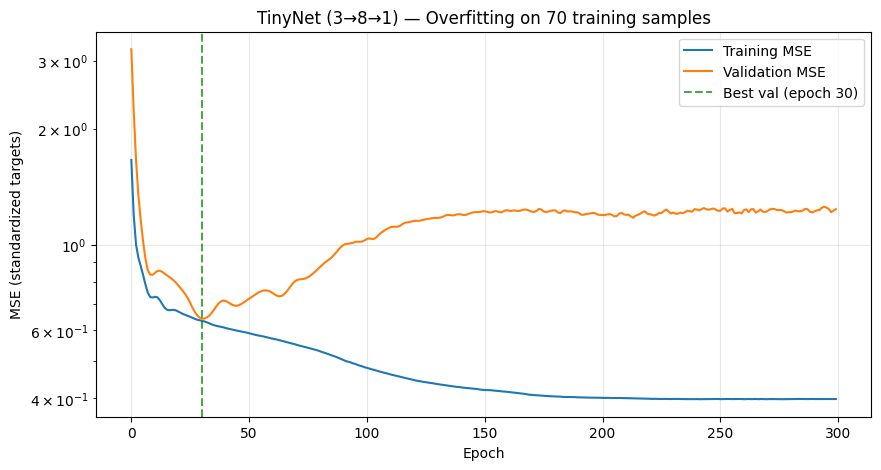

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(tr, label='Training MSE',   linewidth=1.5)
plt.plot(va, label='Validation MSE', linewidth=1.5)
plt.axvline(best_ep, color='green', linestyle='--', alpha=0.7,
            label=f'Best val (epoch {best_ep})')
plt.xlabel('Epoch'); plt.ylabel('MSE (standardized targets)')
plt.title("TinyNet (3→8→1) — Overfitting on 70 training samples")
plt.legend(); plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

The two curves start close, fall together for ~30 epochs, then *diverge*. Training keeps going down; validation turns back up. The widening gap between them is, literally, the model getting *worse* at the thing we care about while looking like it's getting *better* at the thing we don't.

> *"So 'training MSE goes down' isn't progress. It's at best half a story. The other half is the validation MSE."*

Right. This is why every sensible workflow tracks both. Training MSE tells you whether you're learning. Validation MSE tells you whether what you're learning is *useful*.

### **4. Cranking up the capacity — making the failure dramatic**

The small network's overfit is real but mild. Let's see what happens when we point a deliberately oversized model at the same 70 samples — widening the hidden layer from 8 neurons to 128. Same architecture, same data, same optimizer. Just more capacity.


In [4]:
big_net = TinyNet(n_hidden=128, seed=0)
n_params = big_net.W1.size + big_net.b1.size + big_net.W2.size + big_net.b2.size
print(f"Parameters: {n_params}    Training samples: 70    Ratio: {n_params/70:.1f} params per sample")

tr_big, va_big = train_with_val(big_net, X_train, y_train, X_val, y_val, n_epochs=500)

print(f"\n{'Epoch':>6}  {'Train MSE':>10}  {'Val MSE':>10}  {'Gap':>10}")
for ep in [0, 10, 33, 100, 200, 499]:
    print(f"{ep:>6}  {tr_big[ep]:>10.4f}  {va_big[ep]:>10.4f}  {va_big[ep] - tr_big[ep]:>+10.4f}")

best_ep_big = int(np.argmin(va_big))
print(f"\nBest val MSE: {va_big[best_ep_big]:.4f} at epoch {best_ep_big}")
print(f"Final train MSE: {tr_big[-1]:.4f}  (almost zero — full memorization)")
print(f"Final val MSE:   {va_big[-1]:.4f}  (far worse than baseline)")

Parameters: 641    Training samples: 70    Ratio: 9.2 params per sample

 Epoch   Train MSE     Val MSE         Gap
     0      2.5805      2.8536     +0.2731
    10      1.0235      1.4956     +0.4722
    33      0.6221      0.6681     +0.0460
   100      0.3073      0.9393     +0.6320
   200      0.1143      1.3171     +1.2029
   499      0.0198      2.4194     +2.3997

Best val MSE: 0.6681 at epoch 33
Final train MSE: 0.0198  (almost zero — full memorization)
Final val MSE:   2.4194  (far worse than baseline)


By epoch 499 the training MSE is about 0.02 — the network has essentially *memorized* all 70 training points. Meanwhile the validation MSE is 2.42, which means on unseen data the network does **worse than simply predicting the mean** (which would score about 1.0 on standardized targets). It's not just useless; it's actively worse than a coin flip's worth of effort.

> *"Hang on. With 641 parameters and 70 examples, the model hit a training error of 0.02. The data has irreducible noise of 5 points — the targets themselves are partly random! How can it fit them all?"*

That's the key intuition. **With more parameters than data points, the model has enough flexibility to fit *any* targets** — including the noise. Picture a degree-70 polynomial fitting 70 points: it passes through every single one exactly, then wiggles wildly between them. The 128-unit network is doing the same thing in higher dimensions — drawing an absurdly wiggly function that nails every training point and predicts garbage everywhere in between.

This is **memorization without understanding**. The network is no longer learning "more sleep tends to mean higher scores." It's learning "on day 4, where sleep was 7.97 and study was 24.86 and prev_score was 85.83, the answer is 78.23" — for each of 70 specific days. That knowledge is worthless on day 71.


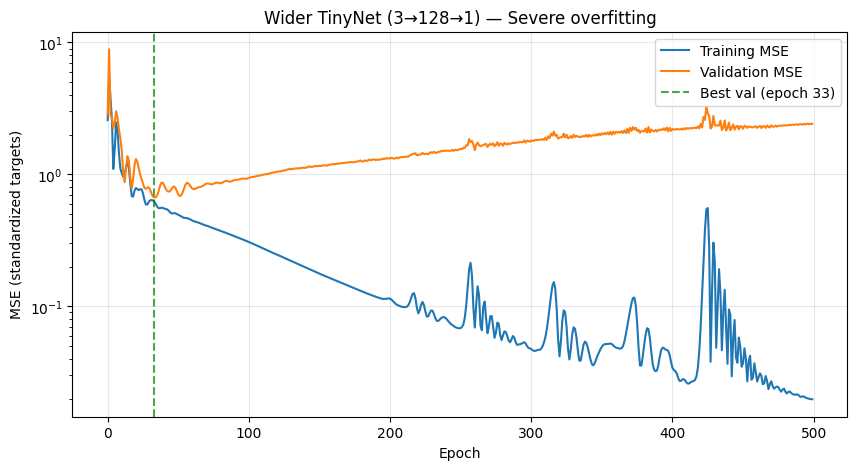

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(tr_big, label='Training MSE',   linewidth=1.5)
plt.plot(va_big, label='Validation MSE', linewidth=1.5)
plt.axvline(best_ep_big, color='green', linestyle='--', alpha=0.7,
            label=f'Best val (epoch {best_ep_big})')
plt.xlabel('Epoch'); plt.ylabel('MSE (standardized targets)')
plt.title("Wider TinyNet (3→128→1) — Severe overfitting")
plt.legend(); plt.grid(alpha=0.3)
plt.yscale('log')
plt.show()

The picture is unmistakable. Both losses fall together for ~30 epochs, then training plunges toward zero while validation rebounds and *climbs past its own starting value*. That's the signature shape — a U on the validation curve, with the best model sitting right at the bottom of the U.

Two takeaways:

1. **Larger networks overfit harder.** With 641 parameters on 70 samples, the gap balloons to 2.4 — far worse than the small network's 0.84.
2. **The best validation MSE is similar across both networks.** The small one hit 0.643 at epoch 30; the wide one hit 0.668 at epoch 33. The wide network's *capability* isn't worse — you just have to stop training at the right moment to use it.

That second point is the seed of Part 4B: **if we know to stop at the right moment, large networks become usable.** Early stopping is one of the simplest forms of regularization, and it works precisely because there *is* a right moment.

### **5. Why does this happen? — the bias–variance tradeoff**

Now for the theory. Why does *every* model — even our humble 41-parameter network — overfit if trained long enough, and why so predictably?

The answer is one of the deepest results in statistics: the **bias–variance decomposition.**

#### **The decomposition**

Suppose the true process is $y = f^*(\mathbf{x}) + \varepsilon$, where $f^*$ is the unknown true function and $\varepsilon$ is irreducible noise with mean zero and variance $\sigma^2$. We train a model $\hat{f}(\mathbf{x}; \boldsymbol{\theta})$ on a finite sample.

Now imagine repeating the whole experiment many times — same process, *different* random training sets each time. We'd get a *distribution* over learned models $\hat{f}$. At a fixed test point $\mathbf{x}_0$, the expected squared error decomposes into exactly three pieces:

$$\mathbb{E}\left[(y_0 - \hat{f}(\mathbf{x}_0))^2\right] = \underbrace{\big(\mathbb{E}[\hat{f}(\mathbf{x}_0)] - f^*(\mathbf{x}_0)\big)^2}_{\text{Bias}^2} + \underbrace{\text{Var}(\hat{f}(\mathbf{x}_0))}_{\text{Variance}} + \underbrace{\sigma^2}_{\text{Irreducible noise}}$$

**Bias** — how far is the *average* prediction (over many possible training sets) from the truth? High bias means *systematically wrong* — too simple to capture the pattern. A straight line trying to fit a curve has high bias: even averaged over many training sets, it's still a line, and it still misses the curve everywhere.

**Variance** — how much does the prediction *change* if you re-train on a different sample from the same distribution? High variance means *unstable* — its answers are dominated by whatever happened to land in this particular training set. A 128-unit network trained on 70 samples will give wildly different predictions if you hand it a different 70.

**Irreducible noise** — the $\sigma^2$ baked into the data. No model can beat it. For our data, $\sigma = 5$ points, so $\sigma^2 = 25$. After standardization (where $\sigma_y \approx 5.16$ for the full dataset), the noise floor on standardized MSE is about $25 / 5.16^2 \approx 0.94$.

Hold onto that last number. **On standardized targets, the best achievable validation MSE for this data is roughly 0.94 — anything lower is fitting through noise.** Our small network hit val MSE 0.64 at its best, which is *below* the floor — confirming what we already suspected back in Part 3. Even our "best" validation score is partly explained by lucky noise alignment between this particular train and val split.

#### **The tradeoff**

The painful truth is that **lowering bias usually raises variance, and vice versa.** Here's the rough shape:

| Model | Bias | Variance | Train MSE | Val MSE |
|---|---|---|---|---|
| Always predict 0 (mean of $y$) | High | Zero | ~1.0 | ~1.0 |
| Linear regression on $\mathbf{x}$ | Medium | Low | ~0.6 | ~0.7 |
| `TinyNet` (3→8→1), epoch 30 | Low | Medium | ~0.6 | ~0.6 |
| `TinyNet` (3→8→1), epoch 299 | Very low (on train) | High | ~0.4 | ~1.2 |
| Wide net (3→128→1), epoch 499 | Near zero (on train) | Very high | ~0.02 | ~2.4 |

Reading down the table:

- The **simplest** model has high bias (wrong on average) but zero variance (it never changes).
- The **most complex** model has near-zero bias on training points (it can fit anything) but enormous variance (its function is so wiggly that small changes in the data move it everywhere).
- The **middle ground** is where validation MSE bottoms out. That sweet spot is what every practitioner is hunting for.

#### **The capacity sweep — the validation curve**

Let's make this concrete by sweeping model capacity and plotting validation error against model size. This is the **validation curve**, one of the most useful diagnostic plots in all of machine learning.


In [6]:
print(f"{'hidden':>6}  {'params':>6}  {'train@best':>11}  {'best val':>9}")

sweep_results = []
for h in [2, 4, 8, 16, 32, 64, 128, 256, 512]:
    net = TinyNet(n_hidden=h, seed=0)
    n_params = net.W1.size + net.b1.size + net.W2.size + net.b2.size
    tr, va = train_with_val(net, X_train, y_train, X_val, y_val, n_epochs=300)
    best_ep = int(np.argmin(va))
    print(f"{h:>6}  {n_params:>6}  {tr[best_ep]:>11.4f}  {va[best_ep]:>9.4f}")
    sweep_results.append((h, n_params, tr[best_ep], va[best_ep]))

hidden  params   train@best   best val
     2      11       0.7068     0.5742
     4      21       0.6117     0.7479
     8      41       0.6350     0.6429
    16      81       0.6642     0.6563
    32     161       0.6493     0.6805
    64     321       0.6830     0.5966
   128     641       0.6221     0.6681
   256    1281       0.7809     0.5649
   512    2561       0.6179     0.6063


Look at the `best val` column. With **early stopping** (we're picking each model at its best validation moment), the best validation MSE is roughly **flat across capacities** — every model hovers between 0.55 and 0.75.

This is a striking finding, and worth stopping on.

> *"Wait. If I stop each model at its best moment, the wide one and the narrow one perform basically the same?"*

Yes. **Capacity doesn't determine your best-case validation performance on this dataset — what matters is whether you stop at the right moment.** The 2-unit network and the 512-unit network can both reach val MSE around 0.6, *if* you halt them at the right epoch.

What capacity *does* control is the *width of the window* during which the model is good. A small network's val curve is shallow — it lingers near its optimum for a long time. A huge network's val curve is sharp — it hits its optimum briefly, then plunges into severe overfit. The 512-unit network bottoms out around MSE 0.61 near epoch 60, then climbs to MSE 1.76 by epoch 499.

That's the second seed of Part 4B: **the techniques we'll add — early stopping, L2, dropout — aren't primarily about a better best-case score. They're about making good performance *robust* across training times and training-set choices.**


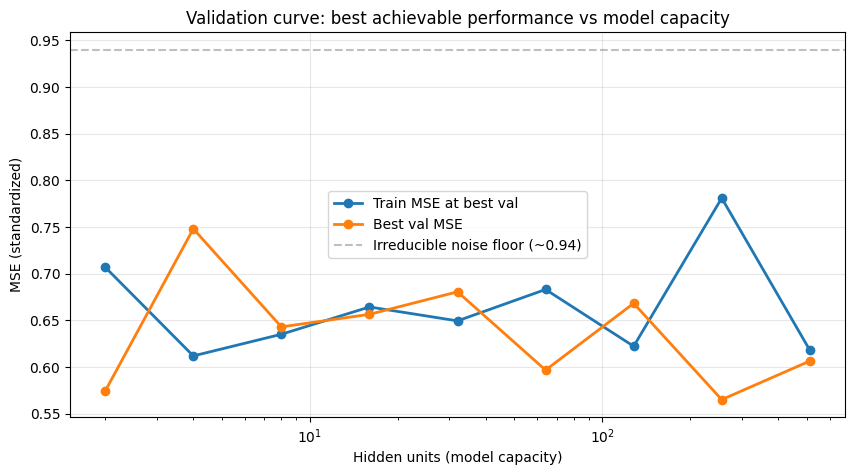

In [7]:
hidden_sizes = [r[0] for r in sweep_results]
train_at_best = [r[2] for r in sweep_results]
best_val      = [r[3] for r in sweep_results]

plt.figure(figsize=(10, 5))
plt.plot(hidden_sizes, train_at_best, 'o-', label='Train MSE at best val',  linewidth=2)
plt.plot(hidden_sizes, best_val,      'o-', label='Best val MSE',           linewidth=2)
plt.axhline(0.94, color='gray', linestyle='--', alpha=0.5,
            label='Irreducible noise floor (~0.94)')
plt.xscale('log')
plt.xlabel('Hidden units (model capacity)')
plt.ylabel('MSE (standardized)')
plt.title('Validation curve: best achievable performance vs model capacity')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The flat shape is the punchline. Capacity alone doesn't change the best-case score much; what changes is how *dangerous* each model is when it's over-trained.

### **6. The five symptoms of overfitting (a diagnostic checklist)**

Before we move to the treatments in Part 4B, here's the practical summary. If you're ever unsure whether a model is overfitting, check these five symptoms:

1. **Training loss is much lower than validation loss.** The gap $\hat{R}_\text{val} - \hat{R}_\text{train}$ should be small. A gap of 0.05 is fine; a gap of 1.0 is a problem.
2. **Training loss is below the noise floor.** If you know roughly how noisy your data is and the model is scoring well under that floor, it's fitting noise. (Don't know the floor? Fine — the other symptoms still work.)
3. **Validation loss has a U-shape over epochs.** Falls early, bottoms out, then rises while training loss keeps falling.
4. **Validation loss is unstable across random splits.** Re-split with a different seed; if val MSE swings wildly, the model has high variance — it's fitting the quirks of each particular split.
5. **The model is much larger than the data.** As a rule of thumb, `params / samples > 10` is a yellow flag; `> 100` means you'd better have a serious regularization story.

Our small `TinyNet` (41 params on 70 samples = 0.59 params/sample) is comfortably fine on symptom 5. But symptoms 1–3 still fired. Overfitting on small datasets is absolutely a thing.

### **What's next — from diagnosis to treatment**

In Part 4A we covered:

| Concept | What it is |
|---|---|
| **Generalization error** | $R(\boldsymbol{\theta}) = \mathbb{E}[L]$ over the true distribution. Unobservable. |
| **Training error** | Loss on data the model was fit on. What we minimize. |
| **Validation error** | Loss on held-out data. Our best estimate of $R$. |
| **Generalization gap** | $\hat{R}_\text{val} - \hat{R}_\text{train}$. The signature of overfitting. |
| **Train/val split protocol** | Split *before* preprocessing. The validation set is sacred. |
| **Bias–variance decomposition** | $\text{Bias}^2 + \text{Variance} + \sigma^2$. Every model lives somewhere on this tradeoff. |
| **Memorization** | When params > data, the network can fit any targets, including noise. |
| **Validation curve** | Best val MSE vs model capacity. Reveals the sweet spot. |

We've established that **even our honest 41-parameter network overfits** if trained for 300 epochs on 70 samples. The "best" model lives at epoch 30, not epoch 299 — and the only way to find epoch 30 is to track validation loss alongside training loss.

Part 4B answers the question this part raises: **what do we do about it?** Specifically —

- **Early stopping** — the simplest regularizer. Stop when val loss stops improving; restore the best weights.
- **L2 regularization (weight decay)** — penalize large weights. Why it shrinks the gap, derived from the gradient.
- **Dropout** — randomly zero out activations during training. Why this acts as an implicit ensemble.
- **Cross-validation** — when one 70/30 split isn't trustworthy, do 5-fold or 10-fold.
- **A final combined model** — in NumPy first (so the maths stays honest), then verified in TensorFlow and PyTorch.
- **Closing thoughts on scaling** — how train/val/test discipline carries from 100 days all the way to billion-parameter models.

> *"So we've correctly diagnosed the disease. Now we need the treatment."*

That's the next post.

---

*All numbers in this tutorial are real outputs from `np.random.seed(42)` plus the explicit class-level seeds. The train/val split was made before standardization. Validation loss was never used for training, only observed. The capacity sweep used the same code path for every hidden-unit count.*
